# Hybrid ResGNN-UNet for Next-Day Wildfire Spread Prediction

This notebook trains a Hybrid ResGNN-UNet (CNN encoder + Graph Attention bottleneck + U-Net decoder) on the NDWS dataset, using the **exact same deterministic 70/15/15 split** as our fire project pipeline.

**Key outputs:**
- `calibration_probability_heatmaps.npz` — for CRC threshold calibration
- `test_probability_heatmaps.npz` — for final evaluation
- Training curves, prediction visualizations, error maps
- Model checkpoint + training metadata

**Setup:** Kaggle notebook with GPU enabled (Settings → Accelerator → GPU T4 x2)

**Dataset:** Already attached — `next-day-wildfire-spread` by fantineh

In [10]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install -q torch-geometric

In [11]:
import os
import json
import glob
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.9.0+cu126 | Device: cuda
GPU: Tesla T4


In [12]:
# ============================================================
# CONFIGURATION — matches fire project exactly
# ============================================================

SEED = 42
TRAIN_FRACTION = 0.70
CALIBRATION_FRACTION = 0.15
# test = 1 - 0.70 - 0.15 = 0.15

# Feature order matches fire/data/constants.py
INPUT_FEATURES = [
    'elevation', 'th', 'vs', 'tmmn', 'tmmx', 'sph',
    'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask',
]
TARGET_FEATURE = 'FireMask'
N_FEATURES = len(INPUT_FEATURES)  # 12

# Training hyperparameters (same as original Kaggle notebook)
HIDDEN_DIM = 64
DROPOUT = 0.3
BATCH_SIZE = 32
LR = 3e-4
WEIGHT_DECAY = 1e-3
POS_WEIGHT = 8.0
NUM_EPOCHS = 25
PATIENCE = 7
GRAD_CLIP = 1.0

# Paths — Kaggle layout
INPUT_DIR = '/kaggle/input/datasets/fantineh/next-day-wildfire-spread'
OUTPUT_DIR = Path('/kaggle/working/resgnn_outputs')
DATA_DIR = Path('/kaggle/working/processed_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Split: {TRAIN_FRACTION:.0%} / {CALIBRATION_FRACTION:.0%} / {1-TRAIN_FRACTION-CALIBRATION_FRACTION:.0%}')
print(f'Seed: {SEED}')

Split: 70% / 15% / 15%
Seed: 42


## 1. Data Loading

Load NDWS TFRecords and apply the **exact same deterministic split** as `fire/data/splits.py`:
- `np.random.default_rng(42).shuffle(indices)`
- First 70% → train, next 15% → calibration, rest → test

In [13]:
# ============================================================
# VERIFY DATASET IS ATTACHED
# ============================================================
tf_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord')))
print(f'Found {len(tf_files)} TFRecord files in {INPUT_DIR}')
assert len(tf_files) == 19, f'Expected 19 TFRecord files, got {len(tf_files)}. Add the dataset: Add Data → next-day-wildfire-spread'

Found 19 TFRecord files in /kaggle/input/datasets/fantineh/next-day-wildfire-spread


In [14]:
# ============================================================
# LOAD TFRECORDS + DETERMINISTIC SPLIT
# ============================================================
import tensorflow as tf

IMG_SHAPE = [64, 64]

features_dict = {
    feat: tf.io.FixedLenFeature(IMG_SHAPE, tf.float32)
    for feat in INPUT_FEATURES + [TARGET_FEATURE]
}

def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, features_dict)
    inputs = tf.stack([parsed[f] for f in INPUT_FEATURES], axis=0)  # (12, 64, 64)
    target = tf.expand_dims(parsed[TARGET_FEATURE], axis=0)         # (1, 64, 64)
    return tf.concat([inputs, target], axis=0)                      # (13, 64, 64)

# Load all samples (tf_files already discovered above)
dataset = tf.data.TFRecordDataset(tf_files)
dataset = dataset.map(parse_tfrecord)

all_data = [sample.numpy() for sample in dataset]
n_total = len(all_data)
print(f'Total samples: {n_total}')

# ---- DETERMINISTIC SPLIT (matches fire/data/splits.py exactly) ----
rng = np.random.default_rng(SEED)
indices = np.arange(n_total, dtype=np.int64)
rng.shuffle(indices)

n_train = int(n_total * TRAIN_FRACTION)
n_cal = int(n_total * CALIBRATION_FRACTION)
n_test = n_total - n_train - n_cal

train_indices = np.sort(indices[:n_train])
cal_indices = np.sort(indices[n_train:n_train + n_cal])
test_indices = np.sort(indices[n_train + n_cal:])

print(f'\nSplit sizes:')
print(f'  Train:       {n_train}')
print(f'  Calibration: {n_cal}')
print(f'  Test:        {n_test}')

# Save as .npy files per split
split_map = {
    'train': train_indices,
    'calibration': cal_indices,
    'test': test_indices,
}

for split_name, split_idx in split_map.items():
    split_dir = DATA_DIR / split_name
    split_dir.mkdir(parents=True, exist_ok=True)
    for i, global_idx in enumerate(split_idx):
        np.save(split_dir / f'sample_{i:05d}.npy', all_data[global_idx])
    print(f'Saved {len(split_idx)} samples to {split_dir}')

# Save split manifest for verification
manifest = {k: v.tolist() for k, v in split_map.items()}
(OUTPUT_DIR / 'split_manifest.json').write_text(json.dumps(manifest))
print(f'\nSplit manifest saved')

# Free memory
del all_data

2026-03-19 16:00:12.542671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773936012.773568      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773936012.840881      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773936013.372830      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773936013.372871      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773936013.372874      55 computation_placer.cc:177] computation placer alr

Total samples: 18545

Split sizes:
  Train:       12981
  Calibration: 2781
  Test:        2783
Saved 12981 samples to /kaggle/working/processed_data/train
Saved 2781 samples to /kaggle/working/processed_data/calibration
Saved 2783 samples to /kaggle/working/processed_data/test

Split manifest saved


In [15]:
# ============================================================
# DATASET CLASS WITH VALID MASK HANDLING
# ============================================================

class WildfireDataset(Dataset):
    """Loads .npy samples with per-sample Z-score normalization and valid masks."""

    def __init__(self, data_dir: Path, split: str, return_sample_id: bool = False):
        split_dir = data_dir / split
        self.files = sorted(split_dir.glob('*.npy'))
        self.return_sample_id = return_sample_id
        print(f'{split}: {len(self.files)} samples')

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        data = np.load(self.files[idx])  # (13, 64, 64)
        x = torch.tensor(data[:N_FEATURES], dtype=torch.float32)  # (12, 64, 64)
        target_raw = data[N_FEATURES]  # (64, 64) — raw FireMask

        # Valid mask: FireMask uses -1 for no-data pixels
        valid_mask = (target_raw >= 0).astype(np.float32)
        target = np.clip(target_raw, 0.0, 1.0).astype(np.float32)

        y = torch.tensor(target, dtype=torch.float32).unsqueeze(0)    # (1, 64, 64)
        mask = torch.tensor(valid_mask, dtype=torch.float32).unsqueeze(0)  # (1, 64, 64)

        # Per-sample Z-score normalization on inputs
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)

        if self.return_sample_id:
            sample_id = self.files[idx].stem  # e.g. 'sample_00042'
            return x, y, mask, sample_id
        return x, y, mask


# Create datasets
train_dataset = WildfireDataset(DATA_DIR, 'train')
cal_dataset = WildfireDataset(DATA_DIR, 'calibration')
test_dataset = WildfireDataset(DATA_DIR, 'test')

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
cal_loader = DataLoader(cal_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nDataloaders: train={len(train_loader)} cal={len(cal_loader)} test={len(test_loader)} batches')

train: 12981 samples
calibration: 2781 samples
test: 2783 samples

Dataloaders: train=406 cal=87 test=87 batches


## 2. Model Architecture

Hybrid ResGNN-UNet: CNN encoder (64→32→16→8) → 3-layer GAT bottleneck with residual → U-Net decoder with skip connections. ~229K parameters.

In [16]:
# ============================================================
# GRID TOPOLOGY + MODEL
# ============================================================

def get_grid_topology(H: int, W: int, device: torch.device) -> torch.Tensor:
    """8-connected grid graph edge_index for HxW spatial grid."""
    src, dst = [], []
    offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    for r in range(H):
        for c in range(W):
            node = r * W + c
            for dr, dc in offsets:
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W:
                    src.append(node)
                    dst.append(nr * W + nc)
    return torch.tensor([src, dst], dtype=torch.long, device=device)


class HybridFireGNN(nn.Module):
    """CNN encoder → GAT bottleneck → U-Net decoder."""

    def __init__(self, in_channels: int = 12, hidden_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout

        # CNN Encoder: 64→32→16→8
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, hidden_dim, 3, 1, 1), nn.BatchNorm2d(hidden_dim), nn.ReLU(), nn.MaxPool2d(2))

        # GAT bottleneck: 3 layers with residual
        self.gat1 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)
        self.gat3 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)

        # U-Net decoder with skip connections
        self.up1 = nn.ConvTranspose2d(hidden_dim, 64, 2, 2)
        self.conv_up1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout2d(dropout))
        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv_up2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout2d(dropout))
        self.up3 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        # Grid → Graph
        B, C, H, W = e3.shape
        x_flat = e3.permute(0, 2, 3, 1).reshape(B * H * W, C)
        single_edges = get_grid_topology(H, W, x.device)
        batched_edges = torch.cat([single_edges + i * (H * W) for i in range(B)], dim=1)

        # 3 GAT layers + residual
        g = F.elu(self.gat1(x_flat, batched_edges))
        g = F.elu(self.gat2(g, batched_edges))
        g = F.elu(self.gat3(g, batched_edges)) + x_flat

        # Graph → Grid
        x_gnn = g.reshape(B, H, W, C).permute(0, 3, 1, 2)

        # Decoder with skip connections
        d1 = self.conv_up1(torch.cat([self.up1(x_gnn), e2], dim=1))
        d2 = self.conv_up2(torch.cat([self.up2(d1), e1], dim=1))
        return self.final(self.up3(d2))  # raw logits


model = HybridFireGNN(in_channels=N_FEATURES, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 229,313


## 3. Training

In [17]:
# ============================================================
# TRAINING LOOP WITH MASKED LOSS + EARLY STOPPING
# ============================================================

# Deterministic training
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
pos_weight = torch.tensor([POS_WEIGHT]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
patience_counter = 0
best_state = None
best_epoch = 0
history = {'train_loss': [], 'val_loss': [], 'lr': []}

print('=' * 60)
print(' Training Hybrid ResGNN-UNet')
print(f' Masked loss | pos_weight={POS_WEIGHT} | AdamW lr={LR}')
print('=' * 60)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss_sum, train_pixels = 0.0, 0
    for x, y, mask in train_loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss_map = criterion(logits, y)
        masked_loss = (loss_map * mask).sum()
        n_valid = mask.sum().clamp(min=1)
        avg_loss = masked_loss / n_valid
        avg_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        train_loss_sum += masked_loss.item()
        train_pixels += int(n_valid.item())

    train_loss = train_loss_sum / max(train_pixels, 1)

    # --- Validate on calibration set ---
    model.eval()
    val_loss_sum, val_pixels = 0.0, 0
    with torch.no_grad():
        for x, y, mask in cal_loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            logits = model(x)
            loss_map = criterion(logits, y)
            masked_loss = (loss_map * mask).sum()
            n_valid = mask.sum().clamp(min=1)
            val_loss_sum += masked_loss.item()
            val_pixels += int(n_valid.item())

    val_loss = val_loss_sum / max(val_pixels, 1)
    lr_now = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(lr_now)

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        patience_counter = 0
        marker = ' ★ Best'
    else:
        patience_counter += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | train: {train_loss:.4f} | val: {val_loss:.4f} | lr: {lr_now:.2e}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

elapsed = time.time() - t0

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
print(f'\nRestored best model from epoch {best_epoch} (val_loss={best_val_loss:.4f})')
print(f'Training time: {elapsed:.0f}s')

 Training Hybrid ResGNN-UNet
 Masked loss | pos_weight=8.0 | AdamW lr=0.0003
Epoch  1/25 | train: 0.2807 | val: 0.1739 | lr: 3.00e-04 ★ Best
Epoch  2/25 | train: 0.1578 | val: 0.1597 | lr: 2.99e-04 ★ Best
Epoch  3/25 | train: 0.1485 | val: 0.1604 | lr: 2.95e-04
Epoch  4/25 | train: 0.1431 | val: 0.1531 | lr: 2.90e-04 ★ Best
Epoch  5/25 | train: 0.1396 | val: 0.1484 | lr: 2.82e-04 ★ Best
Epoch  6/25 | train: 0.1357 | val: 0.1508 | lr: 2.71e-04
Epoch  7/25 | train: 0.1337 | val: 0.1445 | lr: 2.59e-04 ★ Best
Epoch  8/25 | train: 0.1302 | val: 0.1495 | lr: 2.46e-04
Epoch  9/25 | train: 0.1283 | val: 0.1385 | lr: 2.31e-04 ★ Best
Epoch 10/25 | train: 0.1251 | val: 0.1391 | lr: 2.14e-04
Epoch 11/25 | train: 0.1238 | val: 0.1373 | lr: 1.97e-04 ★ Best
Epoch 12/25 | train: 0.1219 | val: 0.1346 | lr: 1.79e-04 ★ Best
Epoch 13/25 | train: 0.1195 | val: 0.1334 | lr: 1.60e-04 ★ Best
Epoch 14/25 | train: 0.1181 | val: 0.1353 | lr: 1.41e-04
Epoch 15/25 | train: 0.1160 | val: 0.1339 | lr: 1.22e-04
Epoch

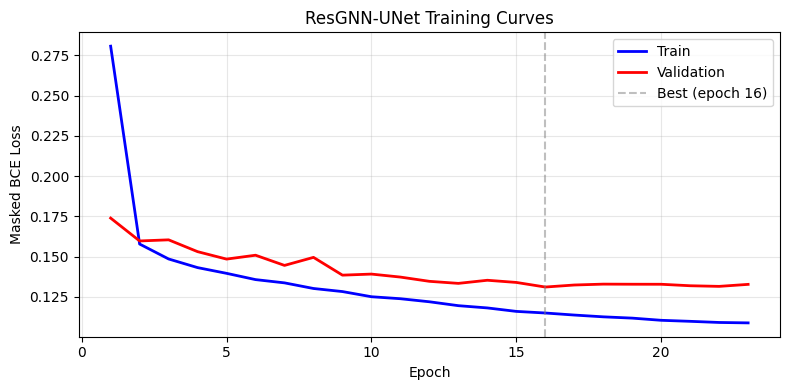

Saved training curves


In [18]:
# ============================================================
# TRAINING CURVES FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], 'b-', lw=2, label='Train')
ax.plot(epochs_range, history['val_loss'], 'r-', lw=2, label='Validation')
ax.axvline(best_epoch, color='gray', ls='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked BCE Loss')
ax.set_title('ResGNN-UNet Training Curves')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resgnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'resgnn_training_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved training curves')

## 4. Export Probability Heatmaps

Export calibration and test set probabilities in the exact format expected by `fire/eval/evaluate.py`:
- NPZ with keys: `probabilities` (float32), `targets` (uint8), `valid_masks` (uint8), `sample_ids`

In [19]:
# ============================================================
# EXPORT CALIBRATION + TEST PROBABILITY HEATMAPS
# ============================================================

@torch.no_grad()
def export_probability_heatmaps(
    model: nn.Module,
    data_dir: Path,
    split_name: str,
    output_dir: Path,
    device: torch.device,
) -> dict:
    """Export probability heatmaps in fire project NPZ format."""
    model.eval()
    ds = WildfireDataset(data_dir, split_name, return_sample_id=True)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    all_probs, all_targets, all_masks, all_ids = [], [], [], []

    for x, y, mask, sample_ids in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[:, 0, :, :]  # (B, 64, 64)
        all_probs.append(probs.astype(np.float32))
        all_targets.append(y.numpy()[:, 0, :, :].astype(np.uint8))
        all_masks.append(mask.numpy()[:, 0, :, :].astype(np.uint8))
        all_ids.extend(sample_ids)

    prob_maps = np.concatenate(all_probs, axis=0)
    target_maps = np.concatenate(all_targets, axis=0)
    valid_masks = np.concatenate(all_masks, axis=0)
    max_len = max(len(s) for s in all_ids)

    output_path = output_dir / f'{split_name}_probability_heatmaps.npz'
    np.savez_compressed(
        output_path,
        split=split_name,
        sample_ids=np.asarray(all_ids, dtype=f'<U{max_len}'),
        targets=target_maps,
        valid_masks=valid_masks,
        probabilities=prob_maps,
    )

    info = {
        'samples': int(prob_maps.shape[0]),
        'height': int(prob_maps.shape[1]),
        'width': int(prob_maps.shape[2]),
        'prob_min': float(prob_maps.min()),
        'prob_max': float(prob_maps.max()),
        'prob_mean': float(prob_maps.mean()),
        'fire_pixels': int(target_maps.sum()),
        'valid_pixels': int(valid_masks.sum()),
    }
    print(f'  {split_name}: {info["samples"]} samples, '
          f'prob range [{info["prob_min"]:.4f}, {info["prob_max"]:.4f}], '
          f'{info["fire_pixels"]:,} fire pixels / {info["valid_pixels"]:,} valid')
    return info


print('Exporting probability heatmaps...')
export_info = {}
for split in ('calibration', 'test'):
    export_info[split] = export_probability_heatmaps(model, DATA_DIR, split, OUTPUT_DIR, device)

print('\nDone! Files saved to', OUTPUT_DIR)

Exporting probability heatmaps...
calibration: 2781 samples
  calibration: 2781 samples, prob range [0.0000, 0.9960], 140,094 fire pixels / 11,116,533 valid
test: 2783 samples
  test: 2783 samples, prob range [0.0000, 0.9974], 129,587 fire pixels / 11,098,212 valid

Done! Files saved to /kaggle/working/resgnn_outputs


In [20]:
# ============================================================
# SAVE CHECKPOINT + METADATA
# ============================================================

# Model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'seed': SEED,
    'input_features': INPUT_FEATURES,
    'target_name': TARGET_FEATURE,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'best_val_loss': best_val_loss,
    'best_epoch': best_epoch,
    'n_params': n_params,
}, OUTPUT_DIR / 'resgnn_checkpoint.pt')

# Training history
(OUTPUT_DIR / 'training_history.json').write_text(json.dumps(history, indent=2))

# Run metadata (matches fire project format)
metadata = {
    'model': 'HybridFireGNN (ResGNN-UNet)',
    'seed': SEED,
    'device': str(device),
    'n_params': n_params,
    'epochs_trained': len(history['train_loss']),
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'pos_weight': POS_WEIGHT,
    'hidden_dim': HIDDEN_DIM,
    'dropout': DROPOUT,
    'input_features': INPUT_FEATURES,
    'target_name': TARGET_FEATURE,
    'split_sizes': {'train': n_train, 'calibration': n_cal, 'test': n_test},
    'exports': export_info,
    'training_time_seconds': round(elapsed, 1),
}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(metadata, indent=2))
print('Saved checkpoint + metadata')

Saved checkpoint + metadata


## 5. Evaluation & Figures

In [21]:
# ============================================================
# TEST SET METRICS
# ============================================================
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    jaccard_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, precision_recall_curve,
)

# Load test heatmaps we just exported
test_data = np.load(OUTPUT_DIR / 'test_probability_heatmaps.npz')
test_probs = test_data['probabilities']    # (N, 64, 64)
test_targets = test_data['targets']         # (N, 64, 64)
test_masks = test_data['valid_masks']       # (N, 64, 64)

# Flatten to valid pixels only
valid = test_masks.astype(bool).ravel()
y_prob = test_probs.ravel()[valid]
y_true = test_targets.ravel()[valid].astype(float)

# Metrics at p >= 0.5
y_pred_50 = (y_prob >= 0.5).astype(float)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_50).ravel()
fnr_50 = fn / (fn + tp) if (fn + tp) > 0 else 0.0
coverage_50 = 1.0 - fnr_50
set_size_50 = y_pred_50.sum() / len(y_pred_50)

# AUROC + AUPRC
roc_auc = roc_auc_score(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)

# F1-optimal threshold
best_f1, best_thresh = 0, 0.5
for t in np.arange(0.1, 0.9, 0.05):
    f1 = f1_score(y_true, (y_prob >= t).astype(float), zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

y_pred_opt = (y_prob >= best_thresh).astype(float)
fnr_opt = ((y_pred_opt == 0) & (y_true == 1)).sum() / (y_true == 1).sum()
coverage_opt = 1.0 - fnr_opt

print('=' * 60)
print(' TEST SET RESULTS')
print('=' * 60)
print(f'  AUROC:          {roc_auc:.4f}')
print(f'  AUPRC:          {auprc:.4f}')
print(f'  Total pixels:   {len(y_prob):,} (valid)')
print(f'  Fire pixels:    {int(y_true.sum()):,} ({100*y_true.mean():.1f}%)')
print()
print(f'  At p >= 0.5:')
print(f'    Coverage:  {coverage_50:.4f}')
print(f'    FNR:       {fnr_50:.4f}')
print(f'    Set size:  {set_size_50:.4f}')
print()
print(f'  At p >= {best_thresh:.2f} (F1-optimal):')
print(f'    Coverage:  {coverage_opt:.4f}')
print(f'    FNR:       {fnr_opt:.4f}')
print(f'    F1:        {best_f1:.4f}')

# Save test metrics
test_metrics = {
    'auroc': roc_auc,
    'auprc': auprc,
    'fnr_at_05': fnr_50,
    'coverage_at_05': coverage_50,
    'set_size_at_05': set_size_50,
    'f1_optimal_threshold': best_thresh,
    'f1_optimal_f1': best_f1,
    'fnr_at_optimal': float(fnr_opt),
    'coverage_at_optimal': float(coverage_opt),
    'n_valid_pixels': int(len(y_prob)),
    'n_fire_pixels': int(y_true.sum()),
}
(OUTPUT_DIR / 'test_metrics.json').write_text(json.dumps(test_metrics, indent=2))

 TEST SET RESULTS
  AUROC:          0.9636
  AUPRC:          0.3768
  Total pixels:   11,098,212 (valid)
  Fire pixels:    129,587 (1.2%)

  At p >= 0.5:
    Coverage:  0.7149
    FNR:       0.2851
    Set size:  0.0311

  At p >= 0.65 (F1-optimal):
    Coverage:  0.5562
    FNR:       0.4438
    F1:        0.4286


409

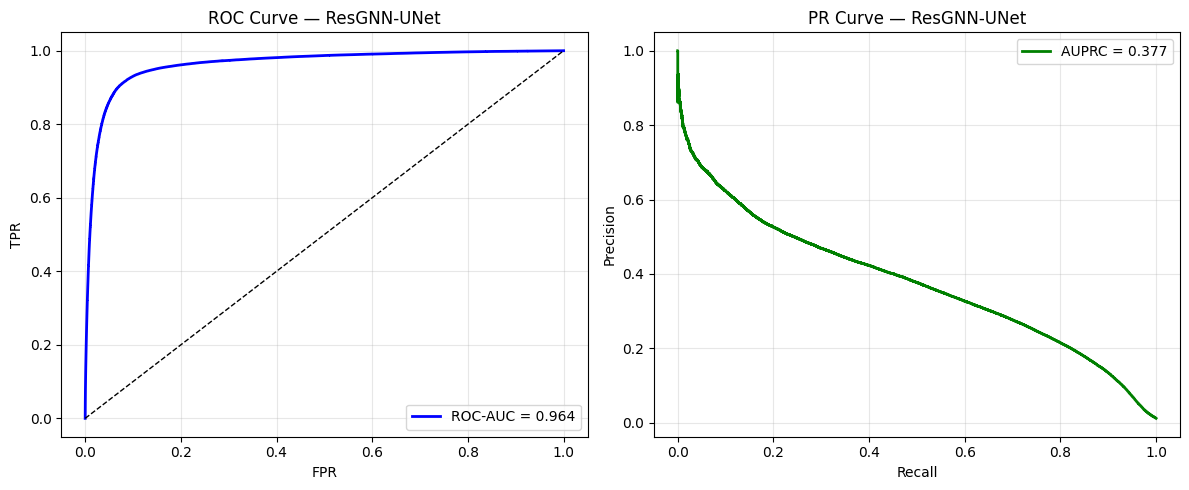

In [22]:
# ============================================================
# ROC + PR CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — ResGNN-UNet')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec_curve, prec_curve, 'g-', lw=2, label=f'AUPRC = {auprc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve — ResGNN-UNet')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resgnn_roc_pr.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'resgnn_roc_pr.pdf', bbox_inches='tight')
plt.show()

test: 2783 samples


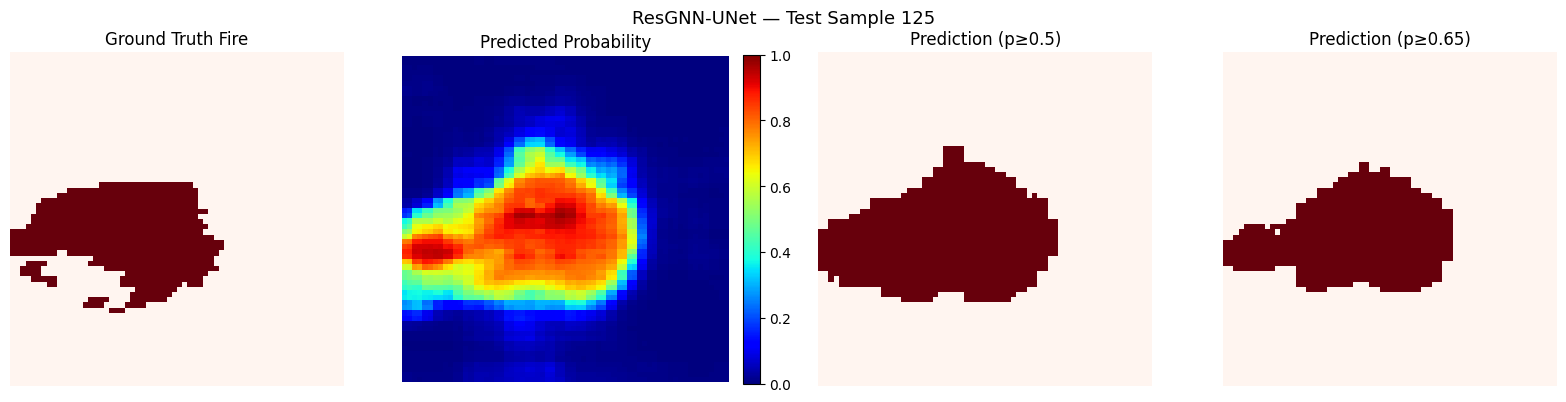

In [23]:
# ============================================================
# PREDICTION VISUALIZATION
# ============================================================

# Find a sample with actual fire pixels for visualization
fire_counts = test_targets.sum(axis=(1, 2))
good_idx = np.argsort(fire_counts)[-5]  # 5th most fire

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Load raw sample to get PrevFireMask
ds_viz = WildfireDataset(DATA_DIR, 'test', return_sample_id=True)
x_viz, y_viz, mask_viz, _ = ds_viz[good_idx]
prev_fire = x_viz[N_FEATURES - 1].numpy()  # PrevFireMask (last input channel, pre-normalization — use raw)

# Use raw target/prob from exported data
target = test_targets[good_idx]
prob = test_probs[good_idx]

axes[0].imshow(target, cmap='Reds', vmin=0, vmax=1)
axes[0].set_title('Ground Truth Fire')
axes[0].axis('off')

im = axes[1].imshow(prob, cmap='jet', vmin=0, vmax=1)
axes[1].set_title('Predicted Probability')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow((prob >= 0.5).astype(float), cmap='Reds', vmin=0, vmax=1)
axes[2].set_title('Prediction (p≥0.5)')
axes[2].axis('off')

axes[3].imshow((prob >= best_thresh).astype(float), cmap='Reds', vmin=0, vmax=1)
axes[3].set_title(f'Prediction (p≥{best_thresh:.2f})')
axes[3].axis('off')

plt.suptitle(f'ResGNN-UNet — Test Sample {good_idx}', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resgnn_prediction_sample.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'resgnn_prediction_sample.pdf', bbox_inches='tight')
plt.show()

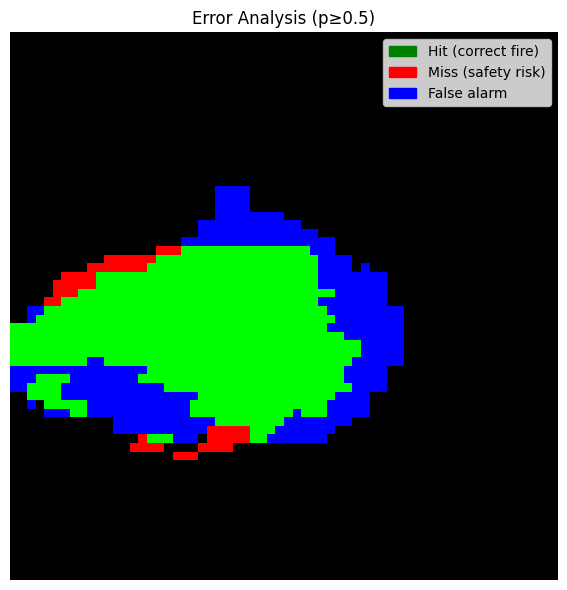

In [24]:
# ============================================================
# ERROR ANALYSIS MAP
# ============================================================

pred_50 = (prob >= 0.5).astype(float)
H, W = target.shape
rgb = np.zeros((H, W, 3))

hit = (target == 1) & (pred_50 == 1)
miss = (target == 1) & (pred_50 == 0)
fa = (target == 0) & (pred_50 == 1)

rgb[hit] = [0, 1, 0]   # green: correct fire
rgb[miss] = [1, 0, 0]  # red: missed fire
rgb[fa] = [0, 0, 1]    # blue: false alarm

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb)
ax.set_title('Error Analysis (p≥0.5)', fontsize=12)
ax.axis('off')

legend_elements = [
    mpatches.Patch(color='green', label='Hit (correct fire)'),
    mpatches.Patch(color='red', label='Miss (safety risk)'),
    mpatches.Patch(color='blue', label='False alarm'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resgnn_error_analysis.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'resgnn_error_analysis.pdf', bbox_inches='tight')
plt.show()

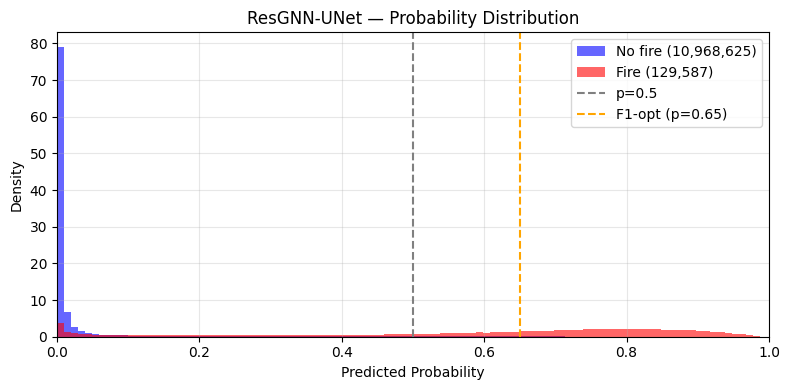

In [25]:
# ============================================================
# PROBABILITY DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))

fire_probs = y_prob[y_true == 1]
nofire_probs = y_prob[y_true == 0]

ax.hist(nofire_probs, bins=100, alpha=0.6, label=f'No fire ({len(nofire_probs):,})', color='blue', density=True)
ax.hist(fire_probs, bins=100, alpha=0.6, label=f'Fire ({len(fire_probs):,})', color='red', density=True)
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='p=0.5')
ax.axvline(best_thresh, color='orange', ls='--', lw=1.5, label=f'F1-opt (p={best_thresh:.2f})')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('ResGNN-UNet — Probability Distribution')
ax.legend()
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resgnn_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'resgnn_prob_distribution.pdf', bbox_inches='tight')
plt.show()

## 6. Download

All outputs are in `/kaggle/working/resgnn_outputs/`. After the notebook finishes:
1. Go to the **Output** tab on the right
2. Download `resgnn_outputs/` folder
3. Place the NPZ files in `data/predictions/graph_baseline/` in the fire project

In [26]:
# ============================================================
# LIST ALL OUTPUTS
# ============================================================
print('Output files:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name:50s} {size_mb:8.2f} MB')

Output files:
  calibration_probability_heatmaps.npz                  40.25 MB
  resgnn_checkpoint.pt                                   0.90 MB
  resgnn_error_analysis.pdf                              0.01 MB
  resgnn_error_analysis.png                              0.02 MB
  resgnn_prediction_sample.pdf                           0.02 MB
  resgnn_prediction_sample.png                           0.04 MB
  resgnn_prob_distribution.pdf                           0.02 MB
  resgnn_prob_distribution.png                           0.04 MB
  resgnn_roc_pr.pdf                                      0.07 MB
  resgnn_roc_pr.png                                      0.07 MB
  resgnn_training_curves.pdf                             0.01 MB
  resgnn_training_curves.png                             0.05 MB
  run_metadata.json                                      0.00 MB
  split_manifest.json                                    0.11 MB
  test_metrics.json                                      0.00 MB
  test_prob

In [27]:
# ============================================================
# PACKAGE AS ZIP (optional — can also download from Output tab)
# ============================================================
import shutil

zip_path = '/kaggle/working/resgnn_outputs_zip'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f'Created {zip_path}.zip')
print('Download from the Output tab on the right →')

Created /kaggle/working/resgnn_outputs_zip.zip
Download from the Output tab on the right →
